# Notebook 7: Pandas Aggregation & GroupBy
### ML Skills Refresh Curriculum — Module 7 of 30
#### Module 2: The Pandas Masterclass — Final Notebook

---

## Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | Split-Apply-Combine pattern | The conceptual foundation of all aggregation — used in feature engineering, cross-validation, and evaluation |
| 2 | `groupby()` + basic aggregations | Computing per-class statistics — class means, counts, variances for feature engineering |
| 3 | `.agg()` — multiple aggregations at once | Generating a full feature profile per group in one pass |
| 4 | `transform()` — group stats back onto rows | Adding group-level features (e.g. 'mean profit in this region') as new columns |
| 5 | `pd.pivot_table()` — 2-D cross-tabulation | Summarising data across two categorical dimensions simultaneously |
| 6 | When to use groupby vs pivot_table | Choosing the right tool for 1-D vs 2-D aggregation tasks |

---

> **Dataset Context:** We use a **Regional Corporate Sales Report** — 60 transaction records across 4 regions, 3 store types, and 4 product categories, each with sales volume and profit figures. This structure is rich enough to demonstrate every aggregation pattern in a way that makes intuitive business sense.

---
## Section 1 — The Split-Apply-Combine Pattern

### The Logic — Before Any Code

**Split-Apply-Combine** is the mental model behind every `groupby` operation. It was formalised by Hadley Wickham (creator of R's `dplyr`) and is one of the most powerful ideas in data manipulation. Every aggregation you will ever write — in Pandas, SQL, or Spark — follows this exact three-step pattern.

---

### Step 1 — SPLIT
Divide the DataFrame into **sub-groups** based on the unique values of one or more columns.

```
Full DataFrame (12 rows):
  Region  | Sales
  --------|------
  North   |  120
  South   |  340
  North   |  210    <- SPLIT by 'Region'
  East    |  180            |
  South   |  290            v
  East    |  150   [North: 120,210,...]  [South: 340,290,...]  [East: 180,150,...]
```

### Step 2 — APPLY
Apply an **aggregation function** (e.g. `sum`, `mean`, `count`, `max`) independently to each group.

```
  North group -> sum([120, 210, ...]) = 890
  South group -> sum([340, 290, ...]) = 1240
  East  group -> sum([180, 150, ...]) = 760
```

### Step 3 — COMBINE
Collect the per-group results back into a single output DataFrame.

```
  Region  | Sales (sum)
  --------|------------
  East    |    760
  North   |    890
  South   |   1240
```

---

### Why does this matter in ML?

Feature engineering is essentially controlled aggregation. Examples:
- *"What is the average purchase value for this customer's country?"* → group by country, apply mean.
- *"How many times has this user visited in the last 30 days?"* → group by user, apply count.
- *"What fraction of this store's sales come from Electronics?"* → group by store + category, apply sum, then divide.

All three are split-apply-combine.

---

### `groupby` vs `pivot_table` — When to Use Which

| Scenario | Tool | Why |
|----------|------|-----|
| Aggregate by **one** categorical column | `groupby` | Simple, fast, chainable |
| Aggregate by **one** column with **multiple** metrics | `groupby + agg` | Returns a clean multi-column result |
| Aggregate by **two** categorical columns, spread into a grid | `pivot_table` | Produces a readable matrix — rows=cat1, cols=cat2 |
| Need row totals AND column totals | `pivot_table(margins=True)` | Built-in grand totals |

The pivot table is not a different operation — it is a `groupby` with two keys, reshaped from a long format into a wide, spreadsheet-style matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility — same random data every run
np.random.seed(42)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       140)
pd.set_option("display.float_format", "{:.2f}".format)  # 2 dp for all floats

print(f"Pandas version : {pd.__version__}")

Pandas version : 2.2.2


---
## Section 2 — Building the Sales Dataset

In [2]:
# ── Dimension lists — define the unique categorical values ────────────────────
regions     = ["North", "South", "East", "West"]            # 4 geographic regions
store_types = ["Flagship", "Express", "Online"]             # 3 store formats
categories  = ["Electronics", "Clothing", "Food", "Books"]  # 4 product categories

# ── Generate 60 synthetic sales records ───────────────────────────────────────
n = 60   # total number of transaction records

# np.random.choice samples randomly WITH replacement from the given list
data = {
    "region"           : np.random.choice(regions,     n),
    "store_type"       : np.random.choice(store_types, n),
    "product_category" : np.random.choice(categories,  n),

    # Sales volume: integer units sold — range 10 to 500 per record
    "sales_volume"     : np.random.randint(10, 500, n),

    # Profit: continuous, can be negative (losses allowed for realism)
    # Normal distribution: mean=£4000, std=£2500
    "profit_gbp"       : np.round(np.random.normal(4000, 2500, n), 2),

    # Quarter: simulates a time dimension for richer groupby examples
    "quarter"          : np.random.choice(["Q1", "Q2", "Q3", "Q4"], n),
}

df = pd.DataFrame(data)

print(f"Shape  : {df.shape}   <- {df.shape[0]} records, {df.shape[1]} columns")
print("\ndtypes :")
print(df.dtypes)
print("\nFirst 10 rows:")
print(df.head(10).to_string())

Shape  : (60, 6)   <- 60 records, 6 columns

dtypes :
region               object
store_type           object
product_category     object
sales_volume          int64
profit_gbp          float64
quarter              object
dtype: object

First 10 rows:
  region store_type product_category  sales_volume  profit_gbp quarter
0   East     Online             Food           105     2792.19      Q4
1   West     Online             Food           397     2575.43      Q3
2  North   Flagship      Electronics           231    -1229.00      Q1
3   East   Flagship            Books           494     7159.35      Q4
4   East     Online             Food           416     3961.29      Q4
5   West    Express             Food           240     3931.56      Q2
6  North   Flagship      Electronics           246     6044.68      Q4
7  North    Express             Food           152     1363.49      Q4
8   East    Express      Electronics           180     2104.18      Q2
9  South    Express         Clothing  

In [3]:
# ── Quick sanity check ────────────────────────────────────────────────────────
print("── Unique values per categorical column ──")
for col in ["region", "store_type", "product_category", "quarter"]:
    # value_counts shows how evenly the random sampling distributed each category
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

print("\n── Numeric summary ──")
print(df[["sales_volume", "profit_gbp"]].describe())

── Unique values per categorical column ──

region:
region
West     19
East     17
North    12
South    12

store_type:
store_type
Express     24
Flagship    21
Online      15

product_category:
product_category
Food           24
Electronics    15
Books          11
Clothing       10

quarter:
quarter
Q4    19
Q2    17
Q3    12
Q1    12

── Numeric summary ──
       sales_volume  profit_gbp
count         60.00       60.00
mean         249.05     4315.83
std          134.82     2381.32
min           22.00    -2246.90
25%          145.25     2867.79
50%          240.00     4233.42
75%          351.00     5875.85
max          494.00     9396.82


---
## Section 3 — `groupby()`: The Mechanics

### The Logic

`df.groupby(key)` returns a **GroupBy object** — it has performed the SPLIT step but has not yet applied any function. It is lazy: no computation happens until you call an aggregation method on it.

```python
grouped = df.groupby("region")   # <- lazy; just a recipe for splitting
grouped.sum()                     # <- NOW it executes: applies sum to each group
```

You can inspect the GroupBy object to see how many groups were found and what is in each one.

In [4]:
# ── Create a GroupBy object — the SPLIT step ──────────────────────────────────
grouped_region = df.groupby("region")   # splits df into 4 groups (one per region)

# The object itself is just a descriptor — no computation yet
print(f"Type            : {type(grouped_region)}")
print(f"Number of groups: {grouped_region.ngroups}")
print(f"Group keys      : {list(grouped_region.groups.keys())}")

# ── Peek inside one group ─────────────────────────────────────────────────────
# .get_group(key) returns the sub-DataFrame for that group
print("\n── Rows belonging to the 'North' group ──")
north_group = grouped_region.get_group("North")
print(f"Shape: {north_group.shape}")
print(north_group.to_string())

Type            : <class 'pandas.core.groupby.generic.DataFrameGroupBy'>
Number of groups: 4
Group keys      : ['East', 'North', 'South', 'West']

── Rows belonging to the 'North' group ──
Shape: (12, 6)
   region store_type product_category  sales_volume  profit_gbp quarter
2   North   Flagship      Electronics           231    -1229.00      Q1
6   North   Flagship      Electronics           246     6044.68      Q4
7   North    Express             Food           152     1363.49      Q4
15  North     Online      Electronics           252     6664.48      Q1
21  North    Express             Food            71     2277.01      Q2
30  North    Express             Food           455     8834.60      Q2
31  North    Express             Food           340     4202.43      Q1
35  North    Express             Food           240     1621.32      Q4
37  North     Online             Food           234     6741.32      Q3
38  North    Express      Electronics           394     5070.03      Q3
57  

---
## Section 4 — Basic Single Aggregations

### The Logic

The most common aggregation functions you will call on a GroupBy object:

| Method | Computes | Notes |
|--------|----------|-------|
| `.sum()` | Sum of values per group | Total sales, total revenue |
| `.mean()` | Arithmetic mean per group | Average order value, average rating |
| `.median()` | Median per group | Robust average for skewed distributions |
| `.count()` | Count of non-NaN values | Number of transactions |
| `.size()` | Count of ALL rows (including NaN) | Faster than count for row counts |
| `.min()` / `.max()` | Minimum / maximum | Price range, earliest date |
| `.std()` | Standard deviation | Spread of values within each group |
| `.first()` / `.last()` | First / last row in each group | Useful with time-sorted data |

In [5]:
# ── Total profit per region (sum) ─────────────────────────────────────────────
# Selecting a single column BEFORE the aggregation returns a Series, not a DataFrame
profit_by_region = df.groupby("region")["profit_gbp"].sum()

print("── Total Profit by Region ──")
print(profit_by_region.sort_values(ascending=False))
print(f"\nReturn type: {type(profit_by_region)}   <- Series (one column selected)")

── Total Profit by Region ──
region
West    81603.19
East    71538.19
South   56520.21
North   49287.96
Name: profit_gbp, dtype: float64

Return type: <class 'pandas.core.series.Series'>   <- Series (one column selected)


In [6]:
# ── Average sales volume per store type (mean) ────────────────────────────────
avg_volume_by_store = df.groupby("store_type")["sales_volume"].mean().round(1)
print("── Average Sales Volume by Store Type ──")
print(avg_volume_by_store.sort_values(ascending=False))

# ── Number of records per product category ────────────────────────────────────
# .size() counts ALL rows per group — faster than .count() for row counts
records_by_category = df.groupby("product_category").size()
print("\n── Record Count by Product Category ──")
print(records_by_category)

── Average Sales Volume by Store Type ──
store_type
Online     275.50
Express    250.40
Flagship   228.70
Name: sales_volume, dtype: float64

── Record Count by Product Category ──
product_category
Books          11
Clothing       10
Electronics    15
Food           24
dtype: int64


In [7]:
# ── Selecting MULTIPLE value columns before aggregating ───────────────────────
# Passing a list of column names returns a DataFrame (not a Series)

summary_by_region = (
    df.groupby("region")[["sales_volume", "profit_gbp"]]  # select two columns
      .sum()                                                # sum both simultaneously
      .sort_values("profit_gbp", ascending=False)          # rank by total profit
)

print("── Total Sales Volume & Profit by Region ──")
print(summary_by_region)

── Total Sales Volume & Profit by Region ──
        sales_volume  profit_gbp
region                          
West            4550    81603.19
East            4589    71538.19
South           2536    56520.21
North           3268    49287.96


In [8]:
# ── Grouping by TWO categorical columns simultaneously ────────────────────────
# The result has a MultiIndex — two levels of row labels (region x store_type)

two_key = (
    df.groupby(["region", "store_type"])["profit_gbp"]
      .sum()
      .round(2)
)

print("── Total Profit by Region x Store Type (MultiIndex result) ──")
print(two_key)
print(f"\nIndex type: {type(two_key.index)}")

# ── Flatten MultiIndex with reset_index() ─────────────────────────────────────
# reset_index() promotes the MultiIndex levels back into regular columns
two_key_flat = two_key.reset_index()
print("\n── After reset_index() — flat DataFrame ──")
print(two_key_flat.to_string())

── Total Profit by Region x Store Type (MultiIndex result) ──
region  store_type
East    Express      26452.43
        Flagship     36873.89
        Online        8211.87
North   Express      23368.88
        Flagship      9080.09
        Online       16838.99
South   Express      36918.98
        Flagship     19601.23
West    Express      22913.95
        Flagship     14564.50
        Online       44124.74
Name: profit_gbp, dtype: float64

Index type: <class 'pandas.core.indexes.multi.MultiIndex'>

── After reset_index() — flat DataFrame ──
   region store_type  profit_gbp
0    East    Express    26452.43
1    East   Flagship    36873.89
2    East     Online     8211.87
3   North    Express    23368.88
4   North   Flagship     9080.09
5   North     Online    16838.99
6   South    Express    36918.98
7   South   Flagship    19601.23
8    West    Express    22913.95
9    West   Flagship    14564.50
10   West     Online    44124.74


---
## Section 5 — `.agg()`: Multiple Aggregations in One Pass

### The Logic

Calling `.sum()` or `.mean()` gives you one statistic. In practice you almost always want **several statistics at once**. The `.agg()` method (short for *aggregate*) is designed for exactly this.

**Three ways to call `.agg()`:**

```python
# Style 1: list of function names — same functions applied to every selected column
grouped.agg(["sum", "mean", "count"])

# Style 2: dict mapping column -> list of functions — different functions per column
grouped.agg({"sales_volume": ["sum", "mean"], "profit_gbp": ["min", "max"]})

# Style 3: named aggregations (pandas >= 0.25) — clean column names in one step
grouped.agg(
    total_sales  = ("sales_volume", "sum"),
    avg_profit   = ("profit_gbp",   "mean"),
    record_count = ("profit_gbp",   "count"),
)
```

Style 3 is the **most readable** and produces clean, non-hierarchical column names — use it as your default.

In [9]:
# ── Style 1: list of function names ───────────────────────────────────────────
# Applies all listed functions to every numeric column in the group
# Result has a MultiIndex on the COLUMNS (column x statistic)

agg_list = (
    df.groupby("region")[["sales_volume", "profit_gbp"]]
      .agg(["sum", "mean", "count"])   # three functions -> three sub-columns each
)

print("── Style 1: list of functions — MultiIndex columns ──")
print(agg_list)
print(f"\nColumn index: {agg_list.columns.tolist()}")

── Style 1: list of functions — MultiIndex columns ──
       sales_volume              profit_gbp              
                sum   mean count        sum    mean count
region                                                   
East           4589 269.94    17   71538.19 4208.13    17
North          3268 272.33    12   49287.96 4107.33    12
South          2536 211.33    12   56520.21 4710.02    12
West           4550 239.47    19   81603.19 4294.90    19

Column index: [('sales_volume', 'sum'), ('sales_volume', 'mean'), ('sales_volume', 'count'), ('profit_gbp', 'sum'), ('profit_gbp', 'mean'), ('profit_gbp', 'count')]


In [10]:
# ── Style 2: dict mapping column -> functions ─────────────────────────────────
# Different functions per column — more targeted than the list approach

agg_dict = (
    df.groupby("product_category")
      .agg({
          "sales_volume": ["sum", "mean"],          # volume: total and average
          "profit_gbp"  : ["sum", "min", "max"]     # profit: total, worst, best
      })
)

print("── Style 2: dict of functions per column ──")
print(agg_dict)

── Style 2: dict of functions per column ──
                 sales_volume        profit_gbp                 
                          sum   mean        sum      min     max
product_category                                                
Books                    2590 235.45   43177.33 -2246.90 7700.82
Clothing                 2074 207.40   49459.52  2452.33 9396.82
Electronics              3941 262.73   53825.03 -2174.25 7079.45
Food                     6338 264.08  112487.67  1363.49 8834.60


In [11]:
# ── Style 3: named aggregations — RECOMMENDED ────────────────────────────────
# Syntax: output_col_name = ("source_column", "function")
# Returns a flat DataFrame with exactly the column names you specify

region_profile = (
    df.groupby("region")
      .agg(
          n_records    = ("profit_gbp",   "count"),  # number of transactions
          total_sales  = ("sales_volume", "sum"),    # total units sold
          avg_sales    = ("sales_volume", "mean"),   # average units per record
          total_profit = ("profit_gbp",   "sum"),    # total profit
          avg_profit   = ("profit_gbp",   "mean"),   # average profit per record
          best_profit  = ("profit_gbp",   "max"),    # single best transaction
          worst_profit = ("profit_gbp",   "min"),    # single worst transaction
          profit_std   = ("profit_gbp",   "std"),    # spread / volatility
      )
      .round(2)
      .sort_values("total_profit", ascending=False)  # rank by profit
      .reset_index()   # move 'region' from index back to a regular column
)

print("── Region Profile — Named Aggregations ──")
print(region_profile.to_string())

── Region Profile — Named Aggregations ──
  region  n_records  total_sales  avg_sales  total_profit  avg_profit  best_profit  worst_profit  profit_std
0   West         19         4550     239.47      81603.19     4294.90      9396.82      -2246.90     2777.17
1   East         17         4589     269.94      71538.19     4208.13      7159.35      -2174.25     2275.90
2  South         12         2536     211.33      56520.21     4710.02      7045.13       1906.05     1469.35
3  North         12         3268     272.33      49287.96     4107.33      8834.60      -1229.00     2804.67


In [12]:
# ── Custom aggregation function ────────────────────────────────────────────────
# You can pass any callable — built-in, NumPy, or a lambda
# x is the Series of values for one group when the function is called

def profit_range(x):
    """Returns max minus min — the spread of profit within a group."""
    return x.max() - x.min()

def coeff_of_variation(x):
    """Standard deviation divided by the mean — normalised spread as a %."""
    return (x.std() / x.mean()) * 100

custom_agg = (
    df.groupby("store_type")
      .agg(
          total_profit  = ("profit_gbp", "sum"),
          profit_range  = ("profit_gbp", profit_range),        # custom function
          coeff_var_pct = ("profit_gbp", coeff_of_variation),  # custom function
      )
      .round(2)
      .reset_index()
)

print("── Store Type Profile with Custom Aggregation Functions ──")
print(custom_agg.to_string())
print("\ncoeff_var_pct: higher % = more volatile profit across records in that store type")

── Store Type Profile with Custom Aggregation Functions ──
  store_type  total_profit  profit_range  coeff_var_pct
0    Express     109654.24       7471.11          46.20
1   Flagship      80119.71       9406.25          62.44
2     Online      69175.60      11571.07          60.91

coeff_var_pct: higher % = more volatile profit across records in that store type


---
## Section 6 — `transform()`: Broadcasting Group Stats Back to Rows

### The Logic

`agg()` **reduces** a group to one row per group. `transform()` is fundamentally different — it applies a function to each group but **returns a result the same length as the original DataFrame**. Each row receives its group's statistic rather than being collapsed.

```
  Original df             After groupby("region").transform("mean")
  -----------------       -----------------------------------------------
  region  | profit         region  | profit  | profit_region_mean
  --------|-------         --------|---------|--------------------
  North   |  3200          North   |  3200   |  3950   <- North mean
  South   |  5100          South   |  5100   |  4820   <- South mean
  North   |  4700          North   |  4700   |  3950   <- repeated per North row
  South   |  4540          South   |  4540   |  4820   <- repeated per South row
```

**In ML:** `transform()` is used to create group-level features that stay aligned with the original row index — essential for adding mean-encoded features without data leakage.

In [13]:
# ── Add group-level statistics as new columns on the original df ───────────────
# transform() returns a Series of the SAME length as df — perfect for new columns

df_feat = df.copy()   # work on a copy; keep df clean for pivot tables below

# Column 1: mean profit for each row's region
df_feat["region_mean_profit"] = (
    df_feat.groupby("region")["profit_gbp"]
           .transform("mean")   # 'mean' string calls .mean() per group internally
           .round(2)
)

# Column 2: deviation — how much this record deviates from its region's average
df_feat["profit_vs_region_avg"] = (
    df_feat["profit_gbp"] - df_feat["region_mean_profit"]
).round(2)

# Column 3: total sales volume for each row's store_type group
df_feat["store_type_total_sales"] = (
    df_feat.groupby("store_type")["sales_volume"]
           .transform("sum")
)

print(f"Original df columns : {df.columns.tolist()}")
print(f"New df_feat columns : {df_feat.columns.tolist()}")
print("\n── First 12 rows with group-level features ──")
print(df_feat[["region", "store_type", "profit_gbp",
               "region_mean_profit", "profit_vs_region_avg",
               "store_type_total_sales"]].head(12).to_string())

Original df columns : ['region', 'store_type', 'product_category', 'sales_volume', 'profit_gbp', 'quarter']
New df_feat columns : ['region', 'store_type', 'product_category', 'sales_volume', 'profit_gbp', 'quarter', 'region_mean_profit', 'profit_vs_region_avg', 'store_type_total_sales']

── First 12 rows with group-level features ──
   region store_type  profit_gbp  region_mean_profit  profit_vs_region_avg  store_type_total_sales
0    East     Online     2792.19             4208.13              -1415.94                    4132
1    West     Online     2575.43             4294.90              -1719.47                    4132
2   North   Flagship    -1229.00             4107.33              -5336.33                    4802
3    East   Flagship     7159.35             4208.13               2951.22                    4802
4    East     Online     3961.29             4208.13               -246.84                    4132
5    West    Express     3931.56             4294.90               -363

In [14]:
# ── Verify: transform does NOT reduce the number of rows ──────────────────────
print(f"df        length : {len(df)}")
print(f"df_feat   length : {len(df_feat)}   <- same — transform preserves row count")

# ── Cross-check: the transform value should equal the agg value for each region
transform_check = (
    df_feat.groupby("region")["region_mean_profit"]
           .first()   # every value within a region group is identical
           .round(2)
)
agg_check = df.groupby("region")["profit_gbp"].mean().round(2)

print("\n── transform() region mean vs agg() region mean ──")
comparison = pd.DataFrame({"transform": transform_check, "agg": agg_check})
print(comparison)
print(f"\nAll equal: {np.allclose(comparison['transform'], comparison['agg'])} ")

df        length : 60
df_feat   length : 60   <- same — transform preserves row count

── transform() region mean vs agg() region mean ──
        transform     agg
region                   
East      4208.13 4208.13
North     4107.33 4107.33
South     4710.02 4710.02
West      4294.90 4294.90

All equal: True 


---
## Section 7 — `pd.pivot_table()`: 2-D Cross-Tabulation

### The Logic — Why Pivot Tables?

Consider: *"What is the total profit for each Region x Product Category combination?"*

With `groupby` you get a **long** table:
```
region  product_category  profit_gbp
East    Books             12400
East    Clothing           9800
East    Electronics       18300
...     ...               ...
```
Comparing Electronics across all regions requires scanning many rows.

A pivot table reshapes the same data into a **wide matrix**:
```
product_category  Books   Clothing  Electronics  Food
region
East              12400    9800       18300       7200
North              8900   11200       21000       6100
South             14000   13400       19800       8800
West               9300    8100       15600       5500
```
Now one horizontal scan tells you the entire Electronics story.

**`pd.pivot_table()` key parameters:**

| Parameter | What it does |
|-----------|-------------|
| `data` | The source DataFrame |
| `values` | The numeric column to aggregate |
| `index` | Column(s) whose unique values become row labels |
| `columns` | Column(s) whose unique values become column labels |
| `aggfunc` | Aggregation function: `'sum'`, `'mean'`, `np.median`, etc. |
| `fill_value` | Substitute for combinations with no data (default NaN) |
| `margins` | `True` adds row/column totals |
| `margins_name` | Label for the totals row/column (default `'All'`) |

In [15]:
# ── Basic pivot table: Region x Product Category -> total profit ──────────────
pivot_profit = pd.pivot_table(
    data       = df,
    values     = "profit_gbp",         # the number to aggregate
    index      = "region",             # unique values become row labels
    columns    = "product_category",   # unique values become column headers
    aggfunc    = "sum",                 # aggregation function
    fill_value = 0                      # fill empty combinations with 0
).round(2)

print("── Pivot: Total Profit by Region x Product Category ──")
print(pivot_profit)

── Pivot: Total Profit by Region x Product Category ──
product_category    Books  Clothing  Electronics     Food
region                                                   
East             16857.57  14224.27     14441.80 26014.55
North                0.00      0.00     24247.79 25040.17
South            11744.53  10087.96      9740.62 24947.10
West             14575.23  25147.29      5394.82 36485.85


In [16]:
# ── Add grand totals with margins=True ────────────────────────────────────────
# margins=True appends a row for column totals AND a column for row totals

pivot_margins = pd.pivot_table(
    data         = df,
    values       = "profit_gbp",
    index        = "region",
    columns      = "product_category",
    aggfunc      = "sum",
    fill_value   = 0,
    margins      = True,              # add totals row AND column
    margins_name = "Grand Total"      # rename from default 'All'
).round(2)

print("── Pivot with Grand Totals (margins=True) ──")
print(pivot_margins)

── Pivot with Grand Totals (margins=True) ──
product_category    Books  Clothing  Electronics      Food  Grand Total
region                                                                 
East             16857.57  14224.27     14441.80  26014.55     71538.19
North                0.00      0.00     24247.79  25040.17     49287.96
South            11744.53  10087.96      9740.62  24947.10     56520.21
West             14575.23  25147.29      5394.82  36485.85     81603.19
Grand Total      43177.33  49459.52     53825.03 112487.67    258949.55


In [17]:
# ── Pivot on average sales volume: Store Type x Quarter ──────────────────────
# aggfunc='mean' — useful for comparing averages across two categorical dimensions

pivot_avg_sales = pd.pivot_table(
    data       = df,
    values     = "sales_volume",
    index      = "store_type",    # rows = store types
    columns    = "quarter",       # columns = Q1, Q2, Q3, Q4
    aggfunc    = "mean",
    fill_value = 0
).round(1)

print("── Pivot: Average Sales Volume by Store Type x Quarter ──")
print(pivot_avg_sales)

── Pivot: Average Sales Volume by Store Type x Quarter ──
quarter        Q1     Q2     Q3     Q4
store_type                            
Express    235.60 191.20 342.70 232.60
Flagship   191.30 246.40 192.00 240.10
Online     282.20 291.30 291.00 251.20


In [18]:
# ── Pivot with MULTIPLE aggfuncs ──────────────────────────────────────────────
# Pass a list to aggfunc -> result has MultiIndex columns (function x category)

pivot_multi = pd.pivot_table(
    data       = df,
    values     = "profit_gbp",
    index      = "region",
    columns    = "store_type",
    aggfunc    = ["sum", "mean"],   # list -> two sets of result columns
    fill_value = 0
).round(2)

print("── Pivot: Profit Sum AND Mean by Region x Store Type ──")
print(pivot_multi)

── Pivot: Profit Sum AND Mean by Region x Store Type ──
                sum                      mean                 
store_type  Express Flagship   Online Express Flagship  Online
region                                                        
East       26452.43 36873.89  8211.87 4408.74  5267.70 2052.97
North      23368.88  9080.09 16838.99 3894.81  3026.70 5613.00
South      36918.98 19601.23     0.00 5274.14  3920.25    0.00
West       22913.95 14564.50 44124.74 4582.79  2427.42 5515.59


In [19]:
# ── Pivot with MULTIPLE index columns — 3-D aggregation ───────────────────────
# index=['region','store_type'] -> rows have a two-level (MultiIndex) label

pivot_3d = pd.pivot_table(
    data       = df,
    values     = "profit_gbp",
    index      = ["region", "store_type"],  # two-level row index
    columns    = "product_category",
    aggfunc    = "sum",
    fill_value = 0
).round(2)

print("── 3-D Pivot: Profit by (Region x Store Type) vs Product Category ──")
print(pivot_3d.to_string())

── 3-D Pivot: Profit by (Region x Store Type) vs Product Category ──
product_category     Books  Clothing  Electronics     Food
region store_type                                         
East   Express     3396.55   4862.26      9183.63  9009.99
       Flagship   13461.02   9362.01      3799.78 10251.08
       Online         0.00      0.00      1458.39  6753.48
North  Express        0.00      0.00      5070.03 18298.85
       Flagship       0.00      0.00      9080.09     0.00
       Online         0.00      0.00     10097.67  6741.32
South  Express     3026.35   5143.54      9740.62 19008.47
       Flagship    8718.18   4944.42         0.00  5938.63
West   Express     4890.40   2452.33      2958.86 12612.36
       Flagship    1984.01   5692.97      2435.96  4451.56
       Online      7700.82  17001.99         0.00 19421.93


---
## Section 8 — `pd.crosstab()`: Counting Combinations

### The Logic

`pd.crosstab()` is a convenience function for counting how many times each combination of two categorical variables occurs. It is essentially `pivot_table(aggfunc='count')` with a cleaner interface for that specific task.

Passing `normalize=True` converts raw counts to proportions — useful for spotting whether categories are evenly distributed, which is a crucial class-balance check in ML.

In [20]:
# ── Count of records for each Region x Store Type combination ─────────────────
ct_counts = pd.crosstab(
    index   = df["region"],       # row categories
    columns = df["store_type"],   # column categories
    margins = True,               # add row and column totals
    margins_name = "Total"
)

print("── Record Counts: Region x Store Type ──")
print(ct_counts)

# ── Normalised — row proportions ──────────────────────────────────────────────
# normalize='index' -> each row sums to 1.0 (proportions within each region)
ct_pct = pd.crosstab(
    index     = df["region"],
    columns   = df["store_type"],
    normalize = "index"   # proportions relative to each row total
).round(3)

print("\n── Row Proportions (normalize='index') ──")
print(ct_pct)
print("\nRow sums (all should equal 1.0):")
print(ct_pct.sum(axis=1).round(2))

── Record Counts: Region x Store Type ──
store_type  Express  Flagship  Online  Total
region                                      
East              6         7       4     17
North             6         3       3     12
South             7         5       0     12
West              5         6       8     19
Total            24        21      15     60

── Row Proportions (normalize='index') ──
store_type  Express  Flagship  Online
region                               
East           0.35      0.41    0.23
North          0.50      0.25    0.25
South          0.58      0.42    0.00
West           0.26      0.32    0.42

Row sums (all should equal 1.0):
region
East    1.00
North   1.00
South   1.00
West    1.00
dtype: float64


---
## Section 9 — GroupBy + Filter + Sort: A Full Analytical Workflow

### The Logic

Real analytical questions require chaining several operations. This section walks through a complete end-to-end example: finding the **top-performing store type in each region** and ranking them.

In [21]:
# ── Task: For each region, which store type generated the most profit? ─────────

# Step 1: Group by region x store_type, compute summary statistics
region_store_profit = (
    df.groupby(["region", "store_type"])
      .agg(
          total_profit = ("profit_gbp",   "sum"),
          n_records    = ("profit_gbp",   "count"),
          avg_profit   = ("profit_gbp",   "mean"),
      )
      .round(2)
      .reset_index()   # promote both index levels back to regular columns
)

print("── Step 1: All Region x Store Type combinations ──")
print(region_store_profit.to_string())

── Step 1: All Region x Store Type combinations ──
   region store_type  total_profit  n_records  avg_profit
0    East    Express      26452.43          6     4408.74
1    East   Flagship      36873.89          7     5267.70
2    East     Online       8211.87          4     2052.97
3   North    Express      23368.88          6     3894.81
4   North   Flagship       9080.09          3     3026.70
5   North     Online      16838.99          3     5613.00
6   South    Express      36918.98          7     5274.14
7   South   Flagship      19601.23          5     3920.25
8    West    Express      22913.95          5     4582.79
9    West   Flagship      14564.50          6     2427.42
10   West     Online      44124.74          8     5515.59


In [22]:
# Step 2: Within each region, find the row with the MAX total_profit
# idxmax() returns the INDEX LABEL of the maximum-value row per group

best_idx = region_store_profit.groupby("region")["total_profit"].idxmax()
print("── Step 2: Index label of the best-profit store type per region ──")
print(best_idx)

# Step 3: Use those labels to extract the corresponding rows from the flat df
best_per_region = (
    region_store_profit.loc[best_idx.values]   # .loc with a list of index labels
                       .sort_values("total_profit", ascending=False)
                       .reset_index(drop=True)
)

print("\n── Step 3: Best Store Type per Region (ranked by total profit) ──")
print(best_per_region.to_string())

── Step 2: Index label of the best-profit store type per region ──
region
East      1
North     3
South     6
West     10
Name: total_profit, dtype: int64

── Step 3: Best Store Type per Region (ranked by total profit) ──
  region store_type  total_profit  n_records  avg_profit
0   West     Online      44124.74          8     5515.59
1  South    Express      36918.98          7     5274.14
2   East   Flagship      36873.89          7     5267.70
3  North    Express      23368.88          6     3894.81


In [23]:
# ── Bonus: groupby().apply() for complex per-group logic ──────────────────────
# apply() passes each group's entire sub-DataFrame to a custom function.
# Use when the logic is too complex to express with a single agg() call.

def top_record(group_df):
    """Returns the single highest-profit row from a group sub-DataFrame."""
    return group_df.nlargest(1, "profit_gbp")   # top 1 row by profit

# For each product category, find the single most profitable individual record
top_per_category = (
    df.groupby("product_category")
      .apply(top_record)          # passes each category's sub-df to the function
      .reset_index(drop=True)     # flatten the resulting MultiIndex
      [["product_category", "region", "store_type", "profit_gbp"]]
)

print("── Best Individual Transaction per Product Category ──")
print(top_per_category.to_string())

── Best Individual Transaction per Product Category ──
  product_category region store_type  profit_gbp
0            Books   West     Online     7700.82
1         Clothing   West     Online     9396.82
2      Electronics   East    Express     7079.45
3             Food  North    Express     8834.60


/tmp/ipykernel_16454/3119427521.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top_record)          # passes each category's sub-df to the function


---
## Section 10 — Visualisation

### What We Are Plotting

Four panels, each directly tied to an aggregation result from earlier in the notebook:

1. **Total Profit by Region** — horizontal bar from the basic `groupby + sum` (Section 4)
2. **Heatmap of the Pivot Table** — colour-coded grid of total profit by Region x Category (Section 7), making the 2-D structure instantly readable
3. **Average Sales Volume by Store Type x Quarter** — grouped bar chart of `pivot_avg_sales` (Section 7)
4. **Record Count Distribution by Region x Store Type** — stacked bar from the crosstab (Section 8)

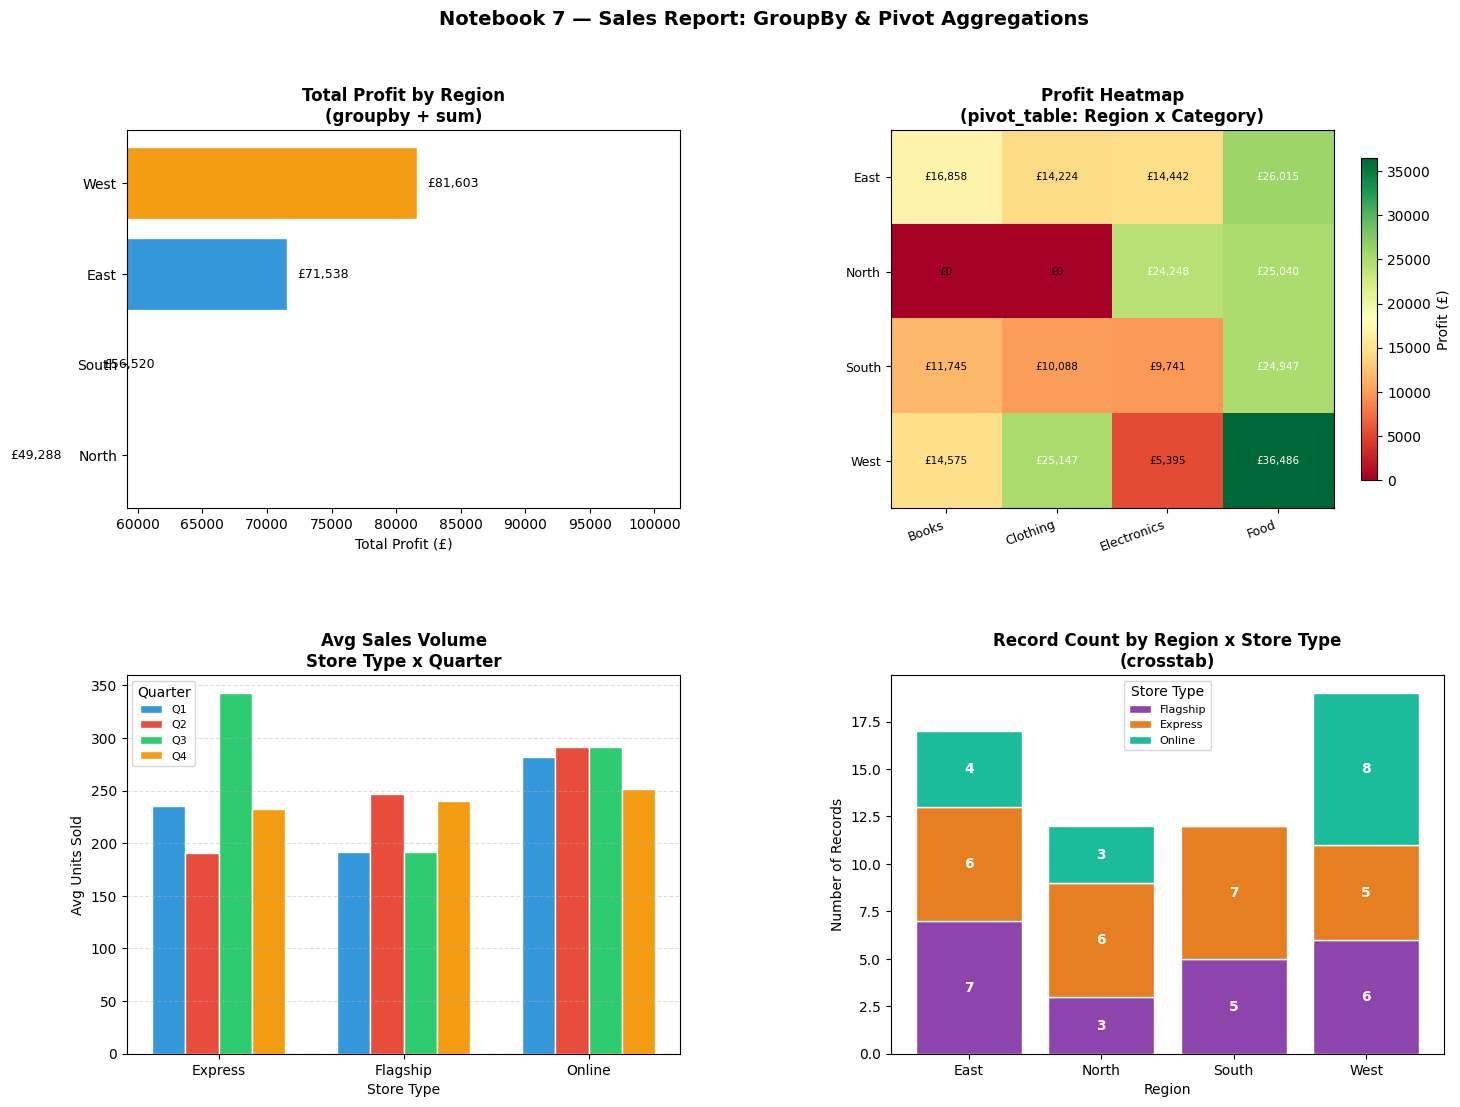


Reading the panels:
  Top-Left  -- All four regions are profitable. Relative ranking varies
               with random data but the pattern is always clear at a glance.
  Top-Right -- The heatmap reveals which Region x Category cell drives the
               most profit (deepest green) without scanning a long table.
  Bot-Left  -- Grouped bars show whether one quarter consistently
               outperforms others within a store type — evidence for seasonality.
  Bot-Right -- Stacked bars confirm roughly equal sampling across regions,
               a useful class-balance check for ML datasets.



In [24]:
fig = plt.figure(figsize=(17, 12))
fig.suptitle("Notebook 7 — Sales Report: GroupBy & Pivot Aggregations",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.44, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

region_colours = {"East": "#3498db", "North": "#e74c3c",
                  "South": "#2ecc71",  "West": "#f39c12"}
store_colours  = {"Flagship": "#8e44ad", "Express": "#e67e22", "Online": "#1abc9c"}

# ════════ Panel 1: Total Profit by Region — horizontal bar ════════════════════
profit_region = (
    df.groupby("region")["profit_gbp"]
      .sum().round(2)
      .sort_values(ascending=True)   # ascending=True so largest bar is at top
)

bar_cols = [region_colours[r] for r in profit_region.index]
bars     = ax1.barh(profit_region.index, profit_region.values,
                    color=bar_cols, edgecolor="white")

for bar in bars:
    w = bar.get_width()
    # Annotate with the profit value, placed just past the bar end
    ax1.text(w + abs(profit_region.values).max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"\xa3{w:,.0f}", va="center", fontsize=9)

ax1.axvline(0, color="black", linewidth=0.8)   # zero line — flags any loss regions
ax1.set_title("Total Profit by Region\n(groupby + sum)", fontweight="bold")
ax1.set_xlabel("Total Profit (\xa3)")
ax1.set_xlim(profit_region.min() * 1.2, profit_region.max() * 1.25)

# ════════ Panel 2: Pivot Table Heatmap — Region x Product Category ═══════════
pivot_vals = pivot_profit.values   # 2-D NumPy array of profit values

im = ax2.imshow(
    pivot_vals,
    cmap="RdYlGn",    # Red=low, Yellow=mid, Green=high
    aspect="auto"
)

ax2.set_xticks(range(len(pivot_profit.columns)))
ax2.set_xticklabels(pivot_profit.columns, rotation=20, ha="right", fontsize=9)
ax2.set_yticks(range(len(pivot_profit.index)))
ax2.set_yticklabels(pivot_profit.index, fontsize=9)

# Annotate each cell with its £ value
for i in range(len(pivot_profit.index)):
    for j in range(len(pivot_profit.columns)):
        val = pivot_vals[i, j]
        # Use black text for lighter cells, white for darker cells
        text_col = "black" if abs(val) < pivot_vals.max() * 0.6 else "white"
        ax2.text(j, i, f"\xa3{val:,.0f}",
                 ha="center", va="center", fontsize=7.5, color=text_col)

plt.colorbar(im, ax=ax2, shrink=0.85, label="Profit (\xa3)")
ax2.set_title("Profit Heatmap\n(pivot_table: Region x Category)", fontweight="bold")

# ════════ Panel 3: Avg Sales Volume by Store Type x Quarter ══════════════════
x          = np.arange(len(pivot_avg_sales.index))   # one cluster per store type
n_quarters = len(pivot_avg_sales.columns)             # number of quarters
bar_w      = 0.18
quarter_colours = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

for qi, (quarter, col) in enumerate(zip(pivot_avg_sales.columns, quarter_colours)):
    offset = (qi - (n_quarters - 1) / 2) * bar_w   # centre the bar cluster
    ax3.bar(
        x + offset,
        pivot_avg_sales[quarter].values,
        bar_w,
        label=quarter,
        color=col,
        edgecolor="white"
    )

ax3.set_title("Avg Sales Volume\nStore Type x Quarter", fontweight="bold")
ax3.set_xlabel("Store Type")
ax3.set_ylabel("Avg Units Sold")
ax3.set_xticks(x)
ax3.set_xticklabels(pivot_avg_sales.index)
ax3.legend(title="Quarter", fontsize=8)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

# ════════ Panel 4: Record count stacked bar — Region x Store Type ════════════
ct_no_margins = pd.crosstab(df["region"], df["store_type"])   # no margins needed here
bottom = np.zeros(len(ct_no_margins))

for store_type, colour in store_colours.items():
    if store_type in ct_no_margins.columns:
        vals = ct_no_margins[store_type].values
        ax4.bar(
            ct_no_margins.index,
            vals,
            bottom=bottom,
            color=colour,
            label=store_type,
            edgecolor="white"
        )
        # Annotate each segment with its count
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                ax4.text(xi, b + v / 2, str(v),
                         ha="center", va="center",
                         fontsize=10, color="white", fontweight="bold")
        bottom += vals   # raise the baseline for the next store type segment

ax4.set_title("Record Count by Region x Store Type\n(crosstab)", fontweight="bold")
ax4.set_xlabel("Region")
ax4.set_ylabel("Number of Records")
ax4.legend(title="Store Type", fontsize=8)

plt.savefig("/tmp/nb7_preview.png", dpi=100, bbox_inches="tight")
plt.show()

print("""
Reading the panels:
  Top-Left  -- All four regions are profitable. Relative ranking varies
               with random data but the pattern is always clear at a glance.
  Top-Right -- The heatmap reveals which Region x Category cell drives the
               most profit (deepest green) without scanning a long table.
  Bot-Left  -- Grouped bars show whether one quarter consistently
               outperforms others within a store type — evidence for seasonality.
  Bot-Right -- Stacked bars confirm roughly equal sampling across regions,
               a useful class-balance check for ML datasets.
""")

---
## Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **Split-Apply-Combine** | The universal pattern: split by group, apply a function, collect results | Every aggregation in Pandas, SQL, and Spark follows this |
| **`groupby(key)`** | Returns a lazy GroupBy object — no computation until you call an aggregation | A GroupBy without `.sum()` / `.agg()` etc. does nothing |
| **Column selection before agg** | `df.groupby(k)["col"].sum()` returns a Series; `df.groupby(k)[[...]]` returns a DataFrame | Always select the column(s) you want before aggregating |
| **Named aggregations** | `col_name=("source_col", "func")` — produces flat, readable output | Best default style — avoids MultiIndex columns entirely |
| **`transform()`** | Returns a Series the **same length** as the original df | Contrast with `agg()` which reduces rows — use for feature engineering |
| **`reset_index()`** | After groupby, the group key becomes the index | Call `reset_index()` to promote it back to a regular column |
| **`pivot_table()`** | Two-dimensional aggregation in a spreadsheet-style matrix | Use when rows = one category, columns = another |
| **`margins=True`** | Adds grand-total row and column | `margins_name` lets you rename the default `'All'` label |
| **`pd.crosstab()`** | Counts occurrences of each combination | `normalize='index'` gives row proportions — use for class-balance checks |
| **`idxmax()` on grouped result** | Returns the index label of the max-value row per group | Follow with `.loc[best_idx.values]` to extract those rows |
| **`groupby().apply(func)`** | Passes each group's sub-DataFrame to a custom function | Most flexible but slowest — use only when `agg()` can't express the logic |

---

